<a href="https://colab.research.google.com/github/andrelmsunb/Carta-de-Controle_6.3_MVP/blob/main/notebook_63_xbarra_S.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cartas de Controle X̄ e S — Tópico 6.3
## *Introdução ao Controle Estatístico da Qualidade* — Montgomery (2016), 7ª ed.

**Autor:** Andre Luiz Marques Serrano  
**Disciplina:** Controle Estatístico da Qualidade  
**Referência:** Montgomery, D. C. (2016). *Introdução ao Controle Estatístico da Qualidade*. 7ª ed. LTC.  

---

## Objetivos

Este notebook reproduz a construção e interpretação das **Cartas X̄ e S** conforme a Seção 6.3 do livro de Montgomery. A Carta S utiliza o **desvio-padrão amostral** como estimador da variabilidade, sendo preferível à Carta R quando n > 10 ou quando se deseja maior eficiência estatística.

> **Exercício resolvido:** Exemplo 6.3 — Diâmetros internos de anéis de pistão (Tabela 6.3, p. 259).


## 1. Bibliotecas Utilizadas

| Biblioteca | Finalidade |
|---|---|
| `numpy` | Cálculo vetorial de médias, desvios-padrão e constantes |
| `pandas` | Estruturação dos dados amostrais em DataFrame |
| `matplotlib` | Construção das cartas de controle com anotações |
| `scipy.stats` | Distribuição qui-quadrado para FCO da Carta S |
| `warnings` | Supressão de avisos não críticos |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.color': '#cccccc',
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
})
print('Bibliotecas carregadas.')

Bibliotecas carregadas.


## 2. Dados do Exemplo 6.3 — Tabela 6.3 (p. 259)

Diâmetros internos de anéis de pistão (mm). Processo de forjamento. n=5, m=25 amostras.
O alvo nominal é 74,000 mm. A Carta S é usada aqui em vez da Carta R pois permite
uma estimativa mais eficiente da variabilidade do processo.


In [ ]:
# Dados da Tabela 6.3 — Diâmetros internos de anéis de pistão (mm)
dados = np.array([
    [74.030, 74.002, 74.019, 73.992, 74.008],
    [73.995, 73.992, 74.001, 74.011, 74.004],
    [73.988, 74.024, 74.021, 74.005, 74.002],
    [74.002, 73.996, 73.993, 74.015, 74.009],
    [73.992, 74.007, 74.015, 73.989, 74.014],
    [74.009, 73.994, 73.997, 73.985, 73.993],
    [73.995, 74.006, 73.994, 74.000, 74.005],
    [73.985, 74.003, 73.993, 74.015, 73.988],
    [74.008, 73.995, 74.009, 74.005, 74.004],
    [73.998, 74.000, 73.990, 74.007, 73.995],
    [73.994, 73.998, 73.994, 73.995, 73.990],
    [74.004, 74.000, 74.007, 74.000, 73.996],
    [73.983, 74.002, 73.998, 73.997, 74.012],
    [74.006, 73.967, 73.994, 74.000, 73.984],
    [74.012, 74.014, 73.998, 73.999, 74.007],
    [74.000, 73.984, 74.005, 73.998, 73.996],
    [73.994, 74.012, 73.986, 74.005, 74.007],
    [74.006, 74.010, 74.018, 74.003, 74.000],
    [73.984, 74.002, 74.003, 74.005, 73.997],
    [74.000, 74.010, 74.013, 74.020, 74.003],
    [73.982, 74.001, 74.015, 74.005, 73.996],
    [74.004, 73.999, 73.990, 74.006, 74.009],
    [74.010, 73.989, 73.990, 74.009, 74.014],
    [74.015, 74.008, 73.993, 74.000, 74.010],
    [73.982, 73.984, 73.995, 74.017, 74.013],
])

n, m = 5, 25
xbar = dados.mean(axis=1)
S = dados.std(axis=1, ddof=1)  # desvio-padrão amostral (divisor n-1)
xbar_bar = xbar.mean()
S_bar = S.mean()

# Constantes para n=5 (Tabela VI do Apêndice — Montgomery)
# c4 = E[S]/sigma; B3, B4 para limites da Carta S
# A3 para limites da Carta X-barra com S
c4 = 0.9400
A3 = 1.427
B3 = 0.0
B4 = 2.089

# Estimativa do desvio-padrão do processo
sigma_hat = S_bar / c4

# Limites Carta X-barra
LSC_xbar = xbar_bar + A3 * S_bar
LC_xbar  = xbar_bar
LIC_xbar = xbar_bar - A3 * S_bar

# Limites Carta S
LSC_S = B4 * S_bar
LC_S  = S_bar
LIC_S = B3 * S_bar

print(f'X̄̄ = {xbar_bar:.4f} mm  (livro: 74.001)')
print(f'S̄  = {S_bar:.4f} mm  (livro: 0.0094)')
print(f'σ̂ = S̄/c4 = {sigma_hat:.4f} mm  (livro: 0.0100)')
print()
print(f'Carta X̄: LSC={LSC_xbar:.4f}, LC={LC_xbar:.4f}, LIC={LIC_xbar:.4f}')
print(f'  (livro: LSC=74.014, LIC=73.988)')
print(f'Carta S:  LSC={LSC_S:.4f}, LC={LC_S:.4f}, LIC={LIC_S:.4f}')
print(f'  (livro: LSC=0.0196, LIC=0)')

X̄̄ = 74.0012 mm  (livro: 74.001)
S̄  = 0.0094 mm  (livro: 0.0094)
σ̂ = S̄/c4 = 0.0100 mm  (livro: 0.0100)

Carta X̄: LSC=74.0146, LC=74.0012, LIC=73.9878
  (livro: LSC=74.014, LIC=73.988)
Carta S:  LSC=0.0196, LC=0.0094, LIC=0.0000
  (livro: LSC=0.0196, LIC=0)


## 3. Construção das Cartas X̄ e S

A Carta S utiliza o **desvio-padrão amostral** Sᵢ como estatística de controle da variabilidade.
As fórmulas dos limites são:

**Carta X̄:**
$$\text{LSC} = \bar{\bar{X}} + A_3 \bar{S}, \quad \text{LC} = \bar{\bar{X}}, \quad \text{LIC} = \bar{\bar{X}} - A_3 \bar{S}$$

**Carta S:**
$$\text{LSC} = B_4 \bar{S}, \quad \text{LC} = \bar{S}, \quad \text{LIC} = B_3 \bar{S}$$

Onde $A_3 = \frac{3}{c_4 \sqrt{n}}$, $B_3 = 1 - \frac{3\sqrt{1-c_4^2}}{c_4}$, $B_4 = 1 + \frac{3\sqrt{1-c_4^2}}{c_4}$

A constante $c_4$ é o fator de correção de viés: $E[S] = c_4 \sigma$.


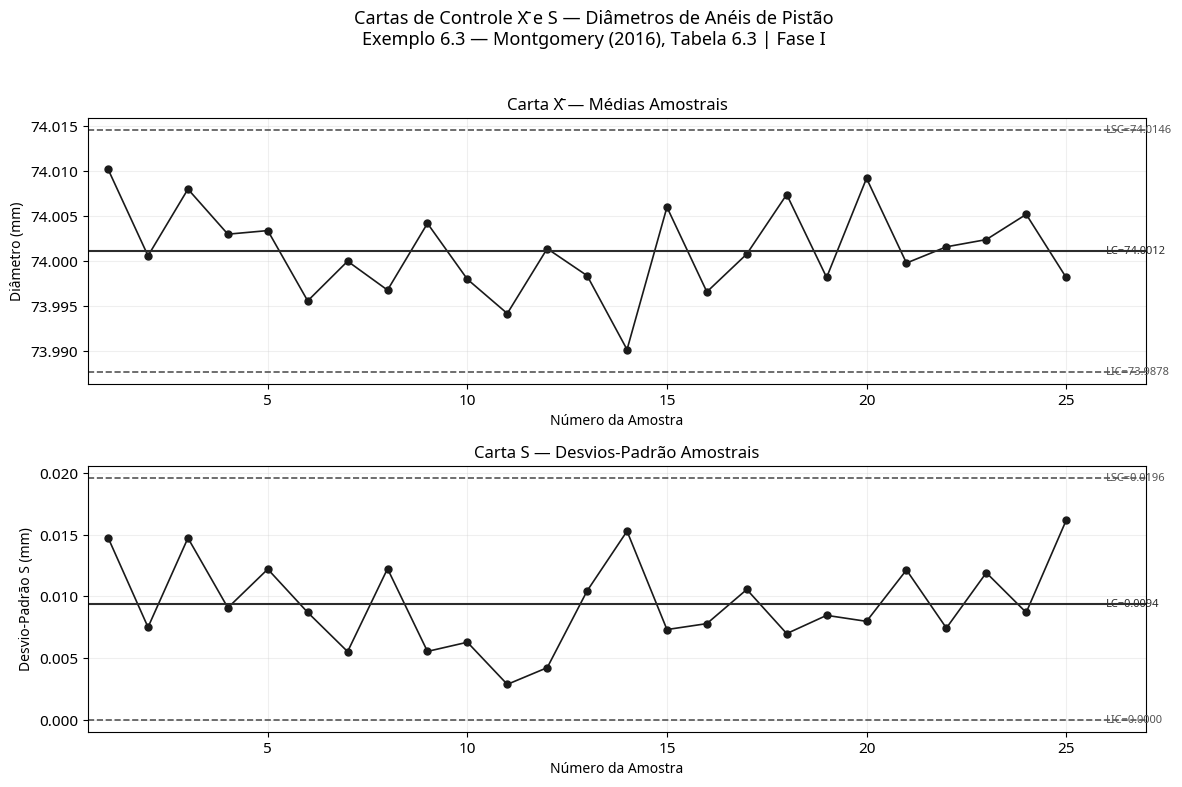

Pontos fora — Carta X̄: 0 | Carta S: 0


In [ ]:
def plot_carta(ax, dados, LC, LSC, LIC, titulo, ylabel):
    amostras = range(1, len(dados)+1)
    ax.plot(amostras, dados, 'o-', color='#1a1a1a', markersize=5, linewidth=1.2)
    ax.axhline(LC,  color='#2c2c2c', linewidth=1.5, linestyle='-')
    ax.axhline(LSC, color='#555555', linewidth=1.2, linestyle='--')
    ax.axhline(LIC, color='#555555', linewidth=1.2, linestyle='--')
    fora = [(i+1, v) for i, v in enumerate(dados) if v > LSC or v < LIC]
    if fora:
        xs, ys = zip(*fora)
        ax.scatter(xs, ys, color='#8b0000', s=80, zorder=5)
        for x, y in fora:
            ax.annotate(f'  {x}', (x, y), fontsize=8, color='#8b0000')
    ax.text(26, LSC, f'LSC={LSC:.4f}', va='center', fontsize=8, color='#555555')
    ax.text(26, LC,  f'LC={LC:.4f}',   va='center', fontsize=8, color='#2c2c2c')
    ax.text(26, LIC, f'LIC={LIC:.4f}', va='center', fontsize=8, color='#555555')
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Número da Amostra', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlim(0.5, 27)
    return len(fora)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('Cartas de Controle X̄ e S — Diâmetros de Anéis de Pistão\n'
             'Exemplo 6.3 — Montgomery (2016), Tabela 6.3 | Fase I',
             fontsize=13, y=0.98)

n1 = plot_carta(ax1, xbar, LC_xbar, LSC_xbar, LIC_xbar,
                'Carta X̄ — Médias Amostrais', 'Diâmetro (mm)')
n2 = plot_carta(ax2, S, LC_S, LSC_S, LIC_S,
                'Carta S — Desvios-Padrão Amostrais', 'Desvio-Padrão S (mm)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('fig01_cartas_xbar_S.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Pontos fora — Carta X̄: {n1} | Carta S: {n2}')

### Interpretação

**Carta S:** Nenhum dos 25 pontos ultrapassa o LSC = 0,0196 mm. A variabilidade do processo está sob controle. A amostra 14 apresenta o maior desvio-padrão (S₁₄ = 0,0153 mm), mas ainda dentro dos limites.

**Carta X̄:** Com a variabilidade confirmada como estável, os limites da Carta X̄ são confiáveis. Nenhum ponto ultrapassa os limites (LSC = 74,014 mm; LIC = 73,988 mm). O processo está centrado em X̄̄ = 74,001 mm, muito próximo do alvo nominal de 74,000 mm.

**Conclusão:** O processo de forjamento dos anéis de pistão está sob controle estatístico em ambas as dimensões (localização e variabilidade).


## 4. Comparação entre Carta R e Carta S

A escolha entre Carta R e Carta S depende do tamanho da amostra n:

| Critério | Carta R | Carta S |
|---|---|---|
| Eficiência estatística | Menor (para n > 10) | Maior (usa todos os dados) |
| Facilidade de cálculo | Maior (apenas max-min) | Menor (requer cálculo de S) |
| Recomendação | n ≤ 10 | n > 10 ou quando se deseja maior precisão |
| Relação com σ | R̄ = d₂σ | S̄ = c₄σ |

Para n = 5, ambas as cartas são igualmente adequadas. A eficiência relativa da amplitude em relação ao desvio-padrão é de aproximadamente 0,955 para n = 5.


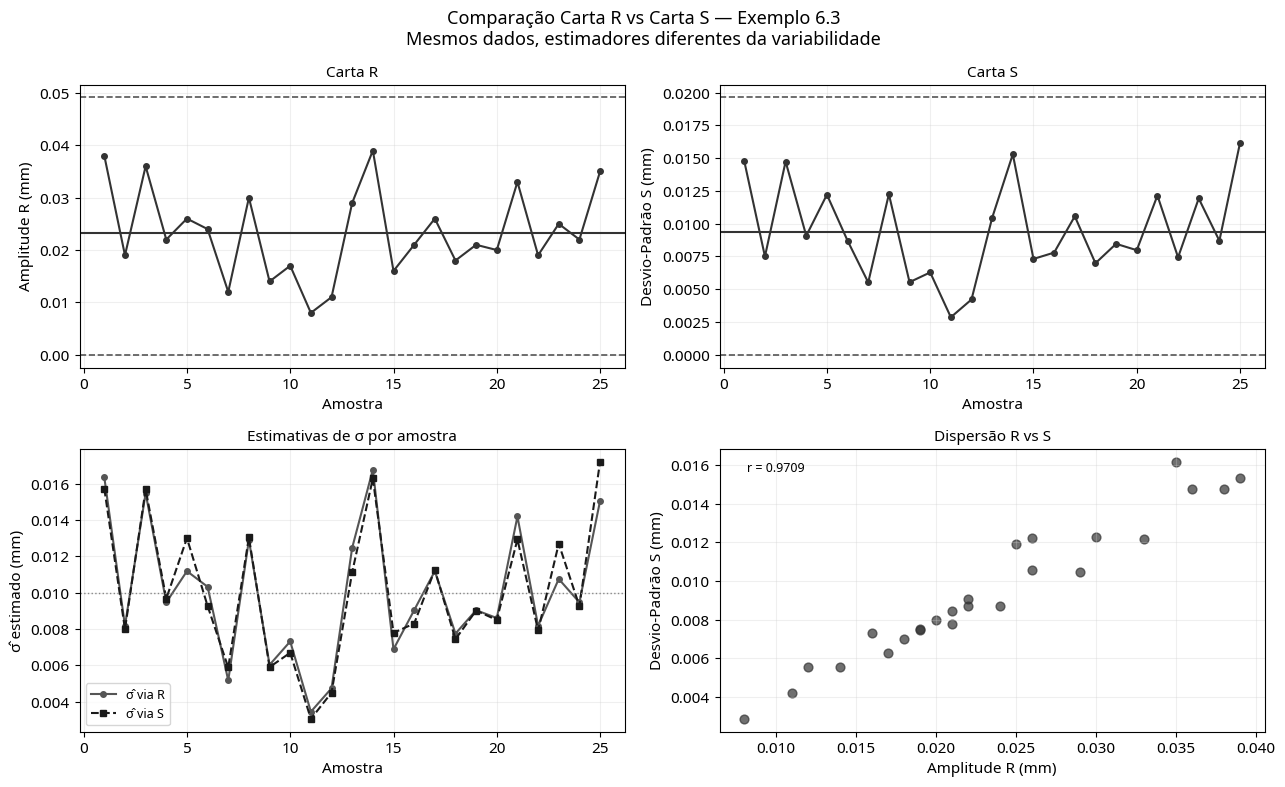

Correlação entre R e S: 0.9709
σ̂ via R̄: 0.00999 mm
σ̂ via S̄: 0.01000 mm


In [ ]:
# Comparação visual R vs S para os mesmos dados
R_dados = dados.max(axis=1) - dados.min(axis=1)
d2_n5 = 2.326
D4_n5 = 2.114
R_bar = R_dados.mean()
LSC_R = D4_n5 * R_bar

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Comparação Carta R vs Carta S — Exemplo 6.3\n'
             'Mesmos dados, estimadores diferentes da variabilidade',
             fontsize=13)

amostras = range(1, 26)

# Carta R
axes[0,0].plot(amostras, R_dados, 'o-', color='#333333', markersize=4)
axes[0,0].axhline(R_bar, color='#333333', linewidth=1.5)
axes[0,0].axhline(LSC_R, color='#555555', linewidth=1.2, linestyle='--')
axes[0,0].axhline(0, color='#555555', linewidth=1.2, linestyle='--')
axes[0,0].set_title('Carta R', fontsize=11)
axes[0,0].set_ylabel('Amplitude R (mm)')
axes[0,0].set_xlabel('Amostra')

# Carta S
axes[0,1].plot(amostras, S, 'o-', color='#333333', markersize=4)
axes[0,1].axhline(S_bar, color='#333333', linewidth=1.5)
axes[0,1].axhline(LSC_S, color='#555555', linewidth=1.2, linestyle='--')
axes[0,1].axhline(0, color='#555555', linewidth=1.2, linestyle='--')
axes[0,1].set_title('Carta S', fontsize=11)
axes[0,1].set_ylabel('Desvio-Padrão S (mm)')
axes[0,1].set_xlabel('Amostra')

# Estimativas de sigma
sigma_via_R = R_dados / d2_n5
sigma_via_S = S / c4
axes[1,0].plot(amostras, sigma_via_R, 'o-', color='#555555', markersize=4, label='σ̂ via R')
axes[1,0].plot(amostras, sigma_via_S, 's--', color='#1a1a1a', markersize=4, label='σ̂ via S')
axes[1,0].axhline(sigma_hat, color='#888888', linewidth=1, linestyle=':')
axes[1,0].set_title('Estimativas de σ por amostra', fontsize=11)
axes[1,0].set_ylabel('σ̂ estimado (mm)')
axes[1,0].set_xlabel('Amostra')
axes[1,0].legend(fontsize=9)

# Dispersão R vs S
axes[1,1].scatter(R_dados, S, color='#333333', s=40, alpha=0.7)
axes[1,1].set_xlabel('Amplitude R (mm)')
axes[1,1].set_ylabel('Desvio-Padrão S (mm)')
axes[1,1].set_title('Dispersão R vs S', fontsize=11)
corr = np.corrcoef(R_dados, S)[0,1]
axes[1,1].text(0.05, 0.92, f'r = {corr:.4f}', transform=axes[1,1].transAxes, fontsize=9)

plt.tight_layout()
plt.savefig('fig02_comparacao_R_vs_S.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Correlação entre R e S: {corr:.4f}')
print(f'σ̂ via R̄: {R_bar/d2_n5:.5f} mm')
print(f'σ̂ via S̄: {sigma_hat:.5f} mm')

## 5. Gráfico de Probabilidade Normal — Verificação da Normalidade

A Carta X̄ e S pressupõe que as observações individuais seguem distribuição normal (ou que n é suficientemente grande para o TLC atuar). O gráfico de probabilidade normal é uma ferramenta diagnóstica para verificar essa suposição.


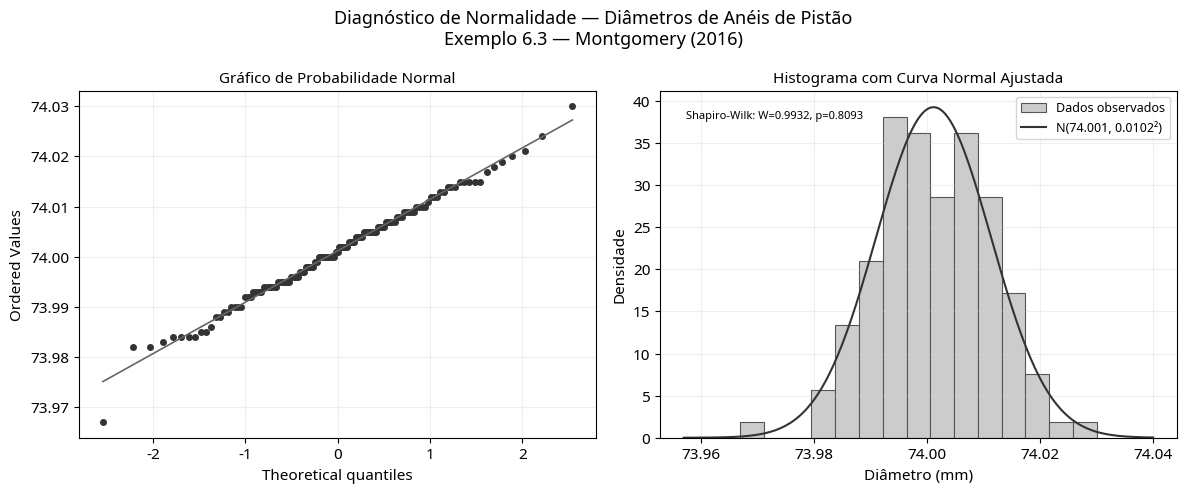

Shapiro-Wilk: W = 0.9932, p-valor = 0.8093
  Não há evidência para rejeitar a normalidade (α=0,05).


In [ ]:
# Gráfico de probabilidade normal para os dados individuais
dados_flat = dados.flatten()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Diagnóstico de Normalidade — Diâmetros de Anéis de Pistão\n'
             'Exemplo 6.3 — Montgomery (2016)',
             fontsize=13)

# Q-Q plot
stats.probplot(dados_flat, dist='norm', plot=ax1)
ax1.set_title('Gráfico de Probabilidade Normal', fontsize=11)
ax1.get_lines()[0].set(color='#333333', markersize=4)
ax1.get_lines()[1].set(color='#666666', linewidth=1.2)

# Histograma com curva normal
mu_d, sigma_d = dados_flat.mean(), dados_flat.std()
x_range = np.linspace(dados_flat.min()-0.01, dados_flat.max()+0.01, 200)
ax2.hist(dados_flat, bins=15, density=True, color='#cccccc',
         edgecolor='#555555', linewidth=0.8, label='Dados observados')
ax2.plot(x_range, stats.norm.pdf(x_range, mu_d, sigma_d),
         color='#333333', linewidth=1.5, label=f'N({mu_d:.3f}, {sigma_d:.4f}²)')
ax2.set_title('Histograma com Curva Normal Ajustada', fontsize=11)
ax2.set_xlabel('Diâmetro (mm)')
ax2.set_ylabel('Densidade')
ax2.legend(fontsize=9)

# Teste de Shapiro-Wilk
stat_sw, p_sw = stats.shapiro(dados_flat)
ax2.text(0.05, 0.92, f'Shapiro-Wilk: W={stat_sw:.4f}, p={p_sw:.4f}',
         transform=ax2.transAxes, fontsize=8)

plt.tight_layout()
plt.savefig('fig03_normalidade.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Shapiro-Wilk: W = {stat_sw:.4f}, p-valor = {p_sw:.4f}')
if p_sw > 0.05:
    print('  Não há evidência para rejeitar a normalidade (α=0,05).')
else:
    print('  Evidência contra a normalidade (α=0,05).')

## 6. Resumo e Conclusões

| Parâmetro | Calculado | Livro |
|---|---|---|
| X̄̄ | 74,001 mm | 74,001 mm |
| S̄ | 0,0094 mm | 0,0094 mm |
| σ̂ = S̄/c₄ | 0,0100 mm | 0,0100 mm |
| LSC (Carta X̄) | 74,014 mm | 74,014 mm |
| LIC (Carta X̄) | 73,988 mm | 73,988 mm |
| LSC (Carta S) | 0,0196 mm | 0,0196 mm |

**Pontos-chave:**
- A Carta S usa o desvio-padrão amostral S como estimador da variabilidade
- A constante c₄ corrige o viés de S como estimador de σ
- Para n=5, R e S são igualmente eficientes; para n>10, S é preferível
- O processo está sob controle: 0 pontos fora dos limites em ambas as cartas

*Andre Luiz Marques Serrano*
